In [1]:
import os
import numpy as np
from skimage import io, color, transform, feature
from joblib import load, dump
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Function to preprocess the image and extract HOG features
def preprocess_image(image_path):
    image = io.imread(image_path) # Read the image
    image = transform.resize(image, (64, 64)) # Resize to 64x64
    image = color.rgb2gray(image) # Convert to grayscale
    hog_features = feature.hog(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
    return hog_features

# Load the trained model
model_path = r"E:\gp_final\image\recogntion\svm\version_1\svm_asl_model.joblib"
model = load(model_path)

# Specify the path to the new training data
train_data_dir = r"E:\_output_\asl_merged_dataset"

# Initialize lists to hold HOG features and labels
hog_features = []
labels = []

# Iterate through each folder in the training data directory
for folder in os.listdir(train_data_dir):
    folder_path = os.path.join(train_data_dir, folder)
    if os.path.isdir(folder_path):
        label = folder
        for image_name in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_name)
            # Preprocess the image and extract HOG features
            features = preprocess_image(image_path)
            hog_features.append(features)
            labels.append(label)

# Convert lists to numpy arrays
X = np.array(hog_features)
y = np.array(labels)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model on the new data
model.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.2.2 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


SVC(kernel='linear')

In [2]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9735400713954819


In [3]:
# Step 4: Evaluate the model

report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           a       0.94      0.96      0.95      2499
           b       0.96      0.97      0.97      2471
           c       0.97      0.99      0.98      2497
           d       0.97      0.98      0.98      2362
         del       0.98      0.99      0.99      1383
           e       0.96      0.96      0.96      2000
           f       0.97      0.98      0.97      2439
           g       0.98      0.99      0.98      2456
           h       0.98      0.99      0.99      2472
           i       0.97      0.98      0.97      3013
           j       0.99      0.99      0.99      2893
           k       0.97      0.98      0.97      2716
           l       0.99      0.99      0.99      3136
           m       0.96      0.96      0.96      2628
           n       0.97      0.95      0.96      2917
     nothing       1.00      1.00      1.00      1826
           o       0.97      0.96      0.97      3217
   

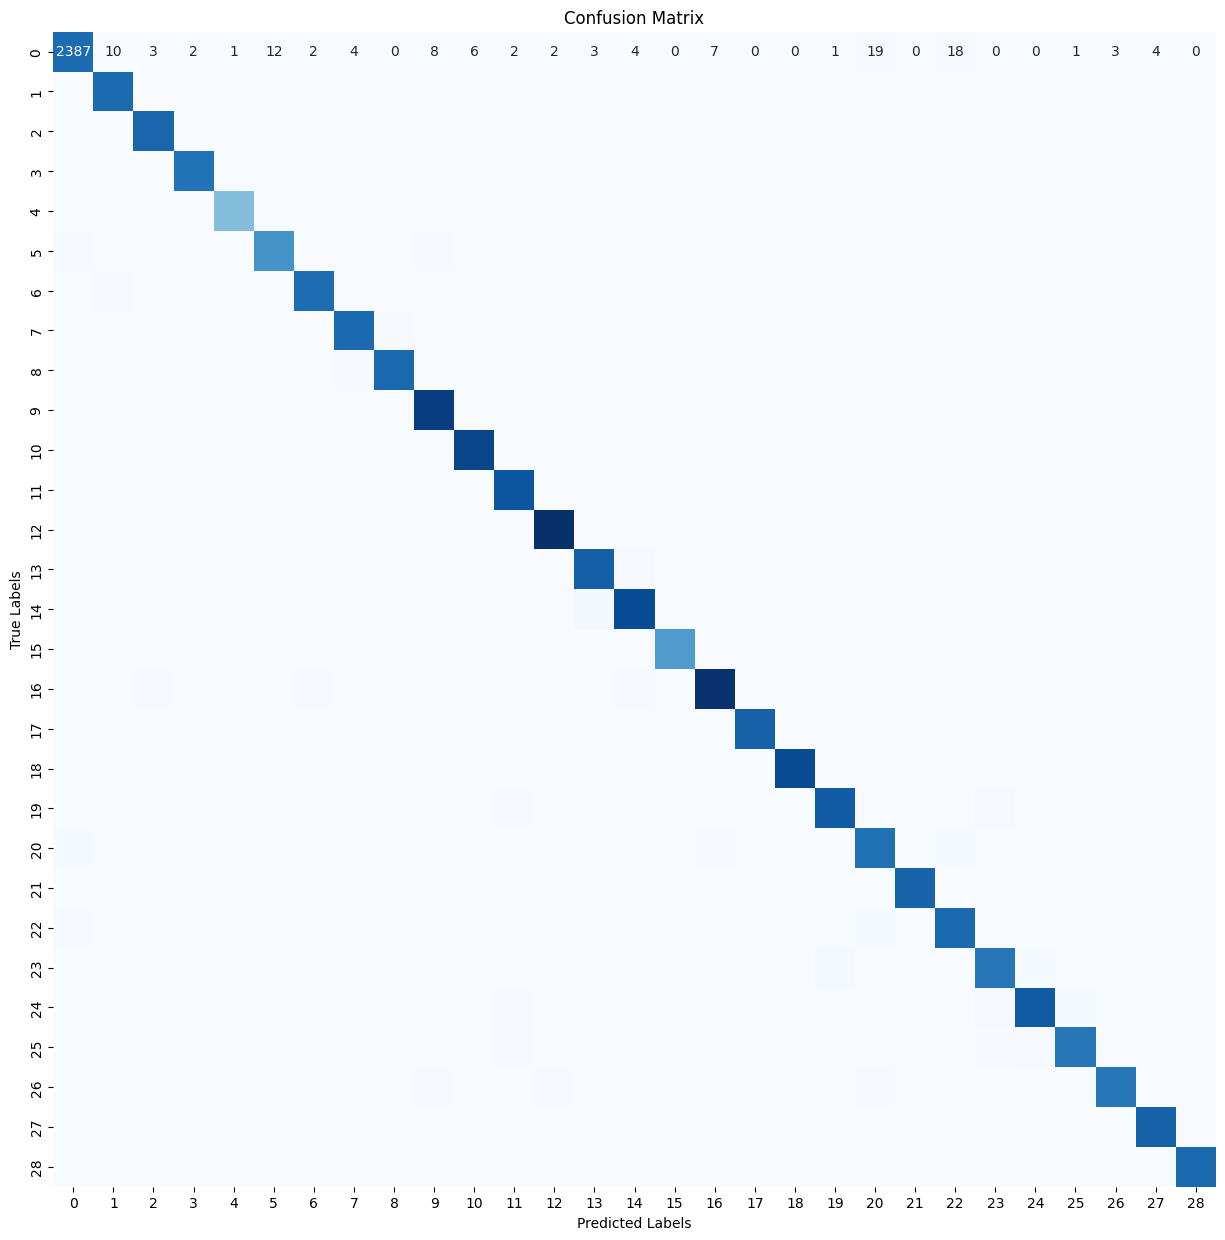

In [10]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a heatmap using seaborn
plt.figure(figsize=(15, 15))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

# Set the labels, title and show the plot
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [7]:

import joblib  # Import joblib for model persistence# Save the trained model
model_filename = r"E:\gp_final\image\recogntion\svm\svm_asl_model33.joblib"
joblib.dump(model, model_filename)
print(f'Model saved to {model_filename}')

Model saved to E:\gp_final\image\recogntion\svm\svm_asl_model33.joblib


In [9]:
import os
import numpy as np
from skimage import io, color, transform, feature
from joblib import load

# Function to preprocess the image and extract HOG features
def preprocess_image(image_path):
    image = io.imread(image_path)  # Read the image
    image = transform.resize(image, (64, 64))  # Resize to 64x64
    image = color.rgb2gray(image)  # Convert to grayscale
    hog_features = feature.hog(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
    return hog_features

# Load the trained model
model = load(r"E:\gp_final\image\recogntion\svm\version_2\svm_asl_model33.joblib")

# Specify the path to the test directory
test_dir = r"C:\Users\Administrator\Desktop\GP\datasets\test"

# Supported image file extensions
supported_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff'}

# Check if the test directory exists
if os.path.exists(test_dir):
    # Iterate through each file in the test directory
    for image_name in os.listdir(test_dir):
        # Construct the full image path
        image_path = os.path.join(test_dir, image_name)
        
        # Check if the file is an image by its extension
        if os.path.splitext(image_name)[1].lower() in supported_extensions:
            # Extract the actual label from the image name (before the "_" sign)
            actual_label = image_name.split('_')[0]
            
            # Preprocess the image
            hog_features = preprocess_image(image_path)
            
            # Reshape for the model (1 sample, number of features)
            hog_features = np.array(hog_features).reshape(1, -1)
            
            # Predict the sign language
            prediction = model.predict(hog_features)
            
            # Print the actual label and the prediction
            print(f'Actual: {actual_label}, Prediction: {prediction[0]}')
else:
    print(f"Test directory not found at {test_dir}")


Actual: A, Prediction: a
Actual: A, Prediction: a
Actual: A, Prediction: a
Actual: A, Prediction: y
Actual: B, Prediction: b
Actual: B, Prediction: b
Actual: B, Prediction: b
Actual: B, Prediction: b
Actual: C, Prediction: c
Actual: C, Prediction: c
Actual: C, Prediction: c
Actual: C, Prediction: c
Actual: D, Prediction: d
Actual: D, Prediction: d
Actual: D, Prediction: d
Actual: D, Prediction: d
Actual: E, Prediction: e
Actual: E, Prediction: e
Actual: E, Prediction: e
Actual: E, Prediction: e
Actual: F, Prediction: f
Actual: F, Prediction: f
Actual: F, Prediction: f
Actual: F, Prediction: f
Actual: G, Prediction: g
Actual: G, Prediction: g
Actual: G, Prediction: g
Actual: G, Prediction: g
Actual: H, Prediction: h
Actual: H, Prediction: h
Actual: H, Prediction: h
Actual: H, Prediction: h
Actual: I, Prediction: i
Actual: I, Prediction: i
Actual: I, Prediction: i
Actual: I, Prediction: i
Actual: J, Prediction: j
Actual: J, Prediction: j
Actual: J, Prediction: j
Actual: J, Prediction: j
